In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1: Newton-Interpolation

Hier berechne ich das Interpolationspolynom in Newton-Darstellung.
Zuerst werden die dividierten Differenzen bestimmt, danach wird das Polynom ausgewertet.
Getestet wird das Ganze fuer f(x)=e^x mit n=10,20,30.

In [2]:
def divided_differences(x, y):
    n = len(x)
    coef = y.astype(float).copy()

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (x[j:n] - x[0:n-j])

    return coef

In [3]:
def newton_evaluate(x_nodes, coef, x_eval):
    n = len(coef)
    p = np.zeros_like(x_eval, dtype=float) + coef[-1]

    for k in range(n - 2, -1, -1):
        p = coef[k] + (x_eval - x_nodes[k]) * p

    return p

In [4]:
def plot_newton_interpolation(f, function_name, n_values):
    x_plot = np.linspace(-1, 1, 1000)
    y_true = f(x_plot)

    for n in n_values:
        number_of_nodes = n + 1

        x_nodes = np.linspace(-1, 1, number_of_nodes)
        y_nodes = f(x_nodes)

        coef = divided_differences(x_nodes, y_nodes)
        y_interp = newton_evaluate(x_nodes, coef, x_plot)

        plt.figure(figsize=(8, 5))
        plt.plot(x_plot, y_true, label=f"Original function {function_name}", linewidth=2)
        plt.plot(x_plot, y_interp, "--", label=f"Newton interpolation, n={n}", linewidth=2)
        plt.scatter(x_nodes, y_nodes, color="red", label="Interpolation nodes", zorder=3)

        plt.title(f"Newton interpolation for {function_name}, n={n}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

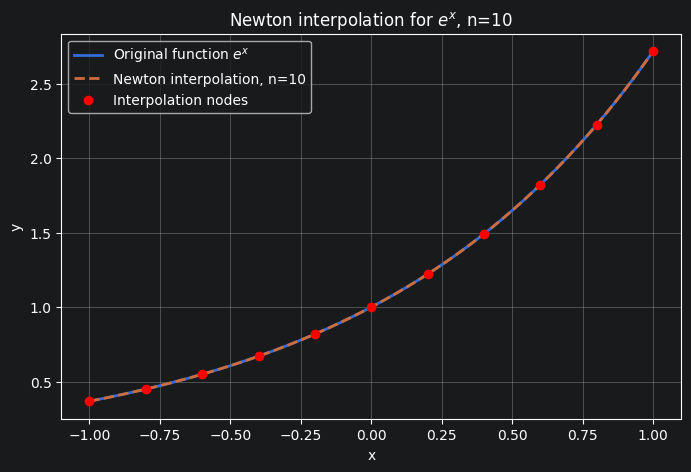

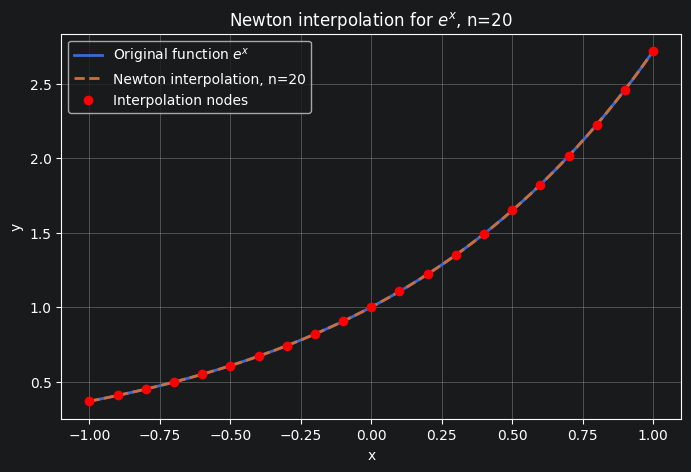

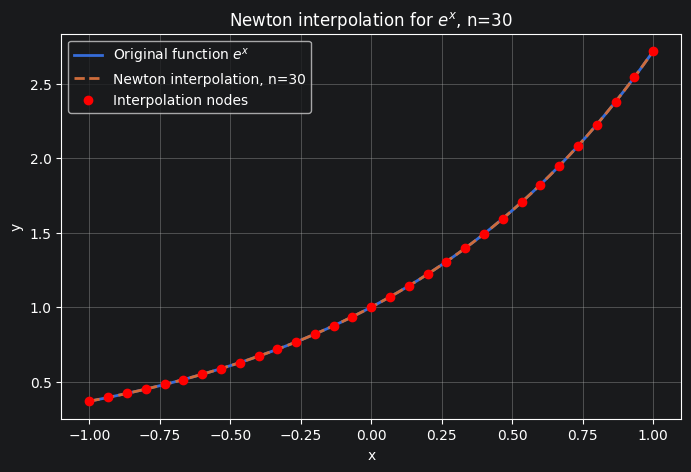

In [5]:
f_exp = lambda x: np.exp(x)

plot_newton_interpolation(
    f=f_exp,
    function_name=r"$e^x$",
    n_values=[10, 20, 30]
)

### Aufgabe 2: Runge-Phaenomen (aequidistante Knoten)

Jetzt wende ich das gleiche Verfahren auf die Runge-Funktion an.
Mit aequidistanten Stuetzstellen sieht man deutlich staerkere Oszillationen am Rand des Intervalls.

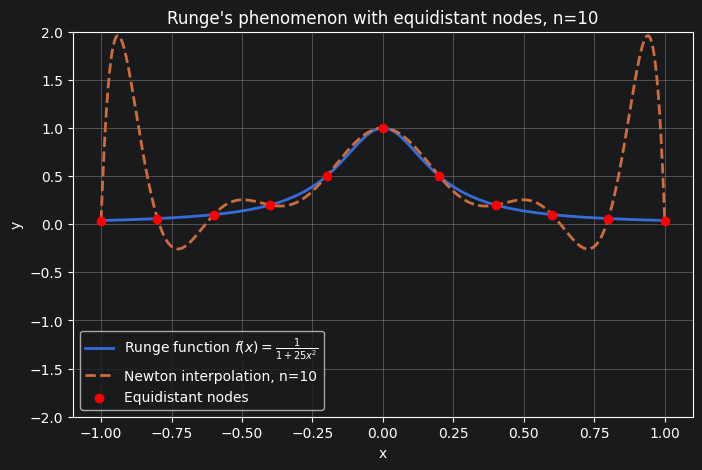

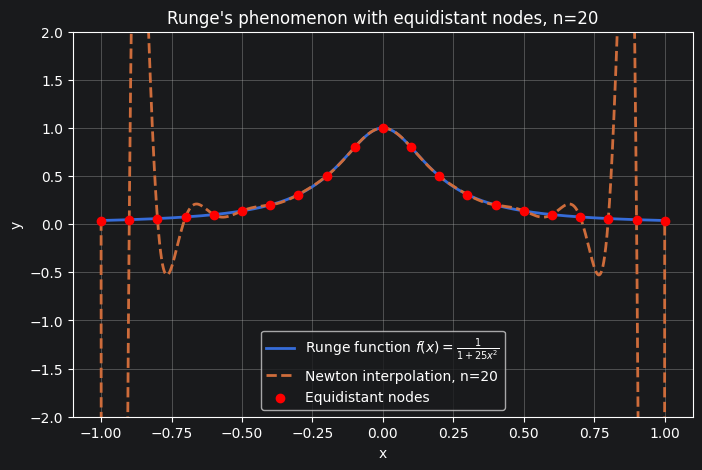

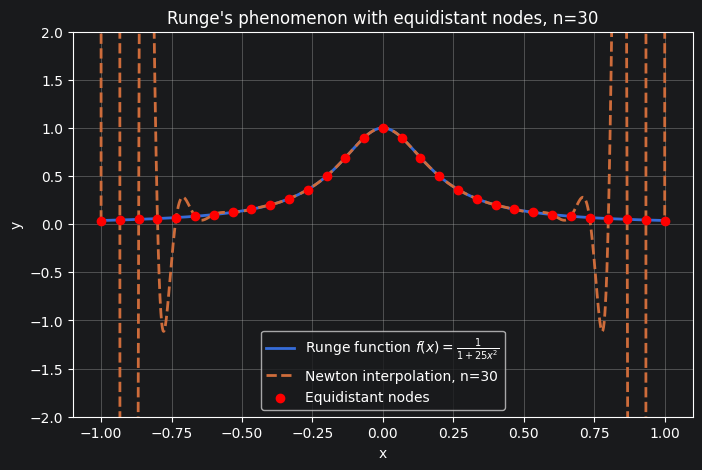

In [6]:
def runge_function(x):
    return 1 / (1 + 25 * x**2)

x_plot = np.linspace(-1, 1, 2000)
y_true = runge_function(x_plot)

for n in [10, 20, 30]:
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = runge_function(x_nodes)

    coef = divided_differences(x_nodes, y_nodes)
    y_interp = newton_evaluate(x_nodes, coef, x_plot)

    plt.figure(figsize=(8, 5))
    plt.plot(x_plot, y_true, label=r"Runge function $f(x)=\frac{1}{1+25x^2}$", linewidth=2)
    plt.plot(x_plot, y_interp, "--", label=f"Newton interpolation, n={n}", linewidth=2)
    plt.scatter(x_nodes, y_nodes, color="red", label="Equidistant nodes", zorder=3)

    plt.title(f"Runge's phenomenon with equidistant nodes, n={n}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.ylim(-2, 2)
    plt.show()

### Aufgabe 3: Runge-Phaenomen mit Tschebyscheff-Knoten

Da aequidistante Knoten schlecht funktionieren, verwende ich hier Tschebyscheff-Knoten 1. und 2. Art.
Damit wird das Interpolationsverhalten deutlich stabiler.

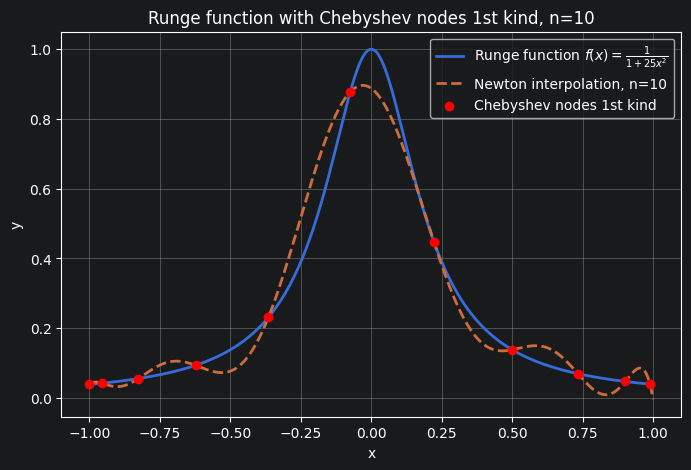

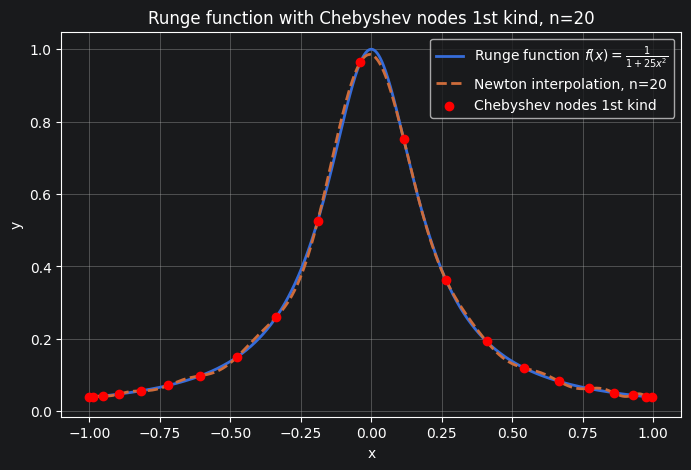

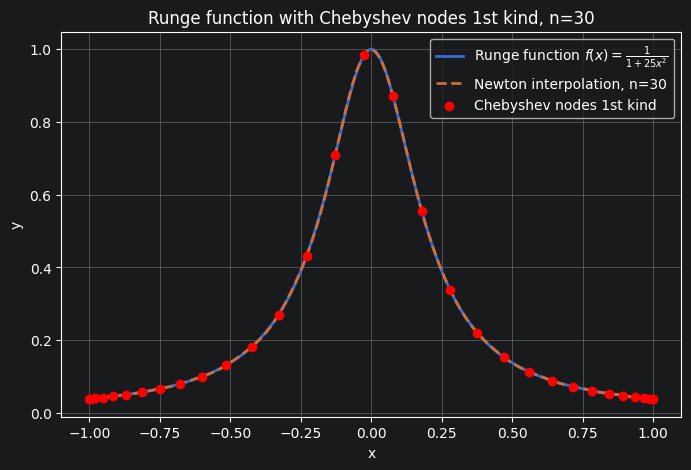

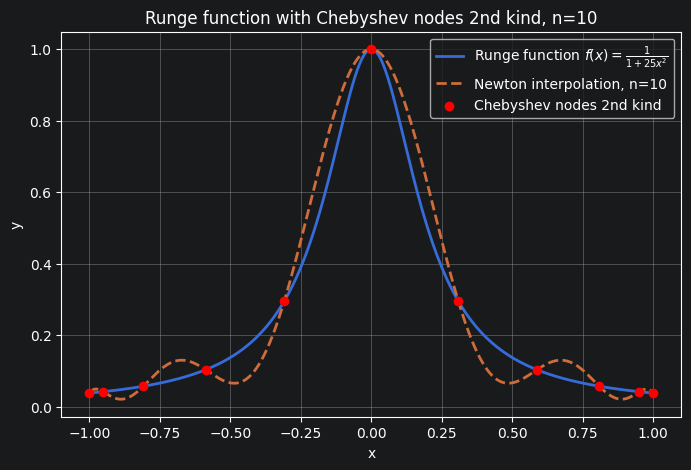

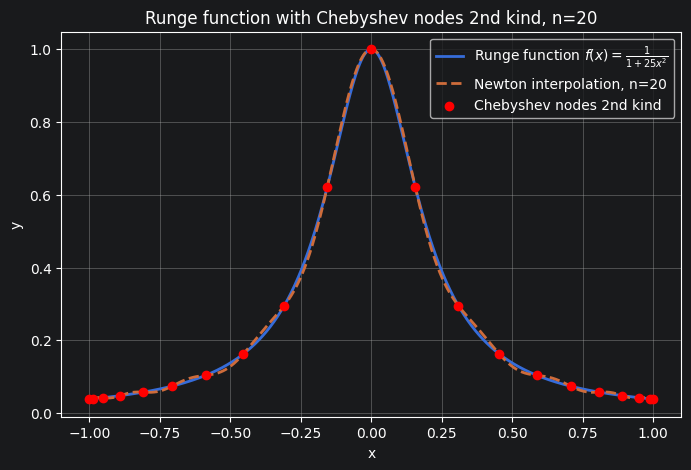

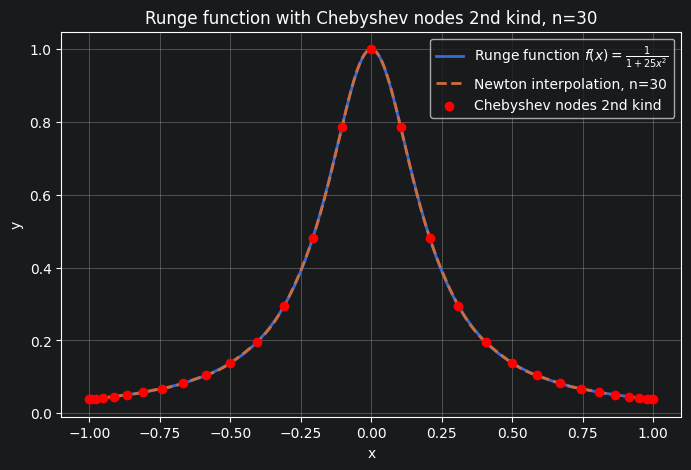

In [7]:
def runge_function(x):
    return 1 / (1 + 25 * x**2)


def chebyshev_nodes_first_kind(n):
    i = np.arange(n + 1)
    return np.cos((2 * i + 1) * np.pi / (2 * n + 1))


def chebyshev_nodes_second_kind(n):
    i = np.arange(n + 1)
    return np.cos(i * np.pi / n)


x_plot = np.linspace(-1, 1, 2000)
y_true = runge_function(x_plot)

for node_type, node_function in [
    ("Chebyshev nodes 1st kind", chebyshev_nodes_first_kind),
    ("Chebyshev nodes 2nd kind", chebyshev_nodes_second_kind)
]:
    for n in [10, 20, 30]:
        x_nodes = node_function(n)
        y_nodes = runge_function(x_nodes)

        coef = divided_differences(x_nodes, y_nodes)
        y_interp = newton_evaluate(x_nodes, coef, x_plot)

        plt.figure(figsize=(8, 5))
        plt.plot(x_plot, y_true, label=r"Runge function $f(x)=\frac{1}{1+25x^2}$", linewidth=2)
        plt.plot(x_plot, y_interp, "--", label=f"Newton interpolation, n={n}", linewidth=2)
        plt.scatter(x_nodes, y_nodes, color="red", label=node_type, zorder=3)

        plt.title(f"Runge function with {node_type}, n={n}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

### Aufgabe 4: Numerische Instabilität bei großem n

Hier teste ich das Newton-Verfahren fuer viele Stuetzstellen (69 und 71).
Man erkennt, dass das Verfahren trotz Tschebyscheff-Knoten numerisch instabil werden kann.

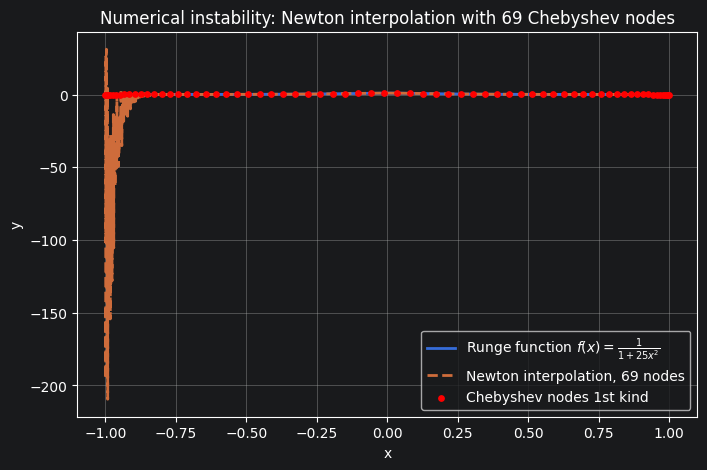

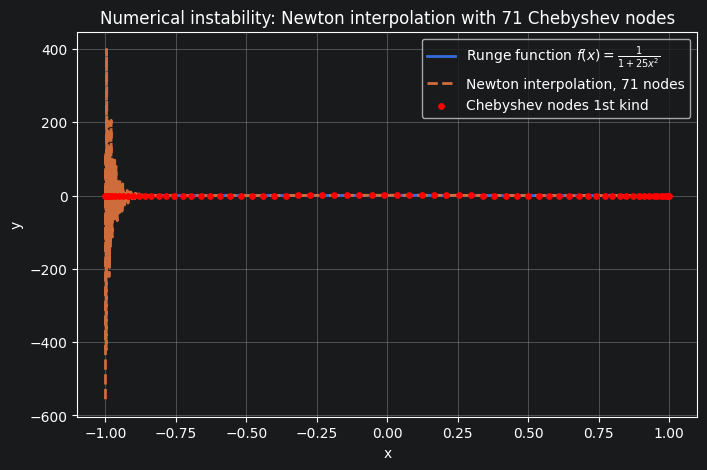

In [8]:
def runge_function(x):
    return 1 / (1 + 25 * x**2)


def chebyshev_nodes_first_kind(n):
    i = np.arange(n + 1)
    return np.cos((2 * i + 1) * np.pi / (2 * n + 1))


x_plot = np.linspace(-1, 1, 3000)
y_true = runge_function(x_plot)

for number_of_nodes in [69, 71]:
    n = number_of_nodes - 1

    x_nodes = chebyshev_nodes_first_kind(n)
    y_nodes = runge_function(x_nodes)

    coef = divided_differences(x_nodes, y_nodes)
    y_interp = newton_evaluate(x_nodes, coef, x_plot)

    plt.figure(figsize=(8, 5))
    plt.plot(x_plot, y_true, label=r"Runge function $f(x)=\frac{1}{1+25x^2}$", linewidth=2)
    plt.plot(x_plot, y_interp, "--", label=f"Newton interpolation, {number_of_nodes} nodes", linewidth=2)
    plt.scatter(x_nodes, y_nodes, color="red", s=15, label="Chebyshev nodes 1st kind", zorder=3)

    plt.title(f"Numerical instability: Newton interpolation with {number_of_nodes} Chebyshev nodes")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.show()